In [10]:
!pip install mediapipe opencv-python

In [11]:
import os
import csv
from pathlib import Path

import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from PIL import Image # PIL is for image processing and manipulation
from tqdm import tqdm # tqdm is for making long running python loops have an interesting progress bar

In [12]:
project_path = Path("/content/drive/MyDrive/ISL_GAN_FewShot_Project")

train_dir = project_path / "data" / "processed" / "fewshot" / "train"
val_dir   = project_path / "data" / "processed" / "fewshot" / "val"
test_dir   = project_path / "data" / "processed" / "fewshot" / "test"

landmark_dir = project_path / "data" / "landmarks"
landmark_dir.mkdir(parents=True, exist_ok=True)

print("Landmark output folder:", landmark_dir)

Landmark output folder: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/landmarks


In [13]:
pip install mediapipe==0.10.14

In [14]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

In [15]:
def extract_hand_landmarks(image_path):
    """
    Returns:
        landmarks: flattened list of 63 values if hand is detected
        or None if no hand is detected
    """
    image = cv2.imread(str(image_path))
    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(image_rgb)

    if not results.multi_hand_landmarks:
        return None

    hand_landmarks = results.multi_hand_landmarks[0]
    landmarks = []

    for lm in hand_landmarks.landmark:
        landmarks.extend([lm.x, lm.y, lm.z])

    return landmarks

In [16]:
def normalize_landmarks(landmarks):
    """
    landmarks: list of 63 values
    Normalize with respect to wrist landmark (landmark 0).
    """
    coords = np.array(landmarks).reshape(-1, 3)
    base = coords[0].copy()
    coords = coords - base
    coords = coords.flatten()
    return coords.tolist()

In [17]:
def process_split(split_dir, split_name, output_csv_path):
    rows = []

    class_folders = [d for d in split_dir.iterdir() if d.is_dir()]
    class_folders = sorted(class_folders)

    for class_dir in class_folders:
        class_name = class_dir.name
        image_files = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))

        for img_path in tqdm(image_files, desc=f"{split_name} - {class_name}", leave=False):
            landmarks = extract_hand_landmarks(img_path)

            if landmarks is None:
                continue

            landmarks = normalize_landmarks(landmarks)

            row = {
                "image_path": str(img_path),
                "class_name": class_name,
                "split": split_name
            }

            for i, val in enumerate(landmarks):
                row[f"f{i}"] = val

            rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(output_csv_path, index=False)
    print(f"Saved {split_name} landmarks to {output_csv_path}")
    print(f"Total samples saved: {len(df)}")
    return df

In [32]:
train_csv = landmark_dir / "train_landmarks.csv"
val_csv   = landmark_dir / "val_landmarks.csv"
test_csv  = landmark_dir / "test_landmarks.csv"

train_df = process_split(train_dir, "train", train_csv)
val_df   = process_split(val_dir, "val", val_csv)
test_df  = process_split(test_dir, "test", test_csv)

train - 1:   0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Saved train landmarks to /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/landmarks/train_landmarks.csv
Total samples saved: 170


Saved val landmarks to /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/landmarks/val_landmarks.csv
Total samples saved: 6236


Saved test landmarks to /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/landmarks/test_landmarks.csv
Total samples saved: 6223


In [33]:
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (170, 66)
Val shape: (6236, 66)
Test shape: (6223, 66)


,image_path,class_name,split,f0,f1,f2,f3,f4,f5,f6,...,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62
0,/content/drive/MyDrive/ISL_GAN_FewShot_Project...,1,train,0.0,0.0,0.0,-0.077316,-0.087751,-0.065280,-0.110893,...,-0.132243,0.188523,-0.230272,-0.190905,0.126916,-0.162720,-0.160921,0.106000,-0.129952,-0.123364
1,/content/drive/MyDrive/ISL_GAN_FewShot_Project...,1,train,0.0,0.0,0.0,-0.077175,-0.088306,-0.062049,-0.112554,...,-0.138453,0.187230,-0.234030,-0.197816,0.125944,-0.165063,-0.169637,0.100889,-0.131132,-0.133264
2,/content/drive/MyDrive/ISL_GAN_FewShot_Project...,1,train,0.0,0.0,0.0,-0.077674,-0.085278,-0.069531,-0.120188,...,-0.147987,0.201501,-0.238279,-0.211987,0.132505,-0.163941,-0.180470,0.113698,-0.133430,-0.140707
3,/content/drive/MyDrive/ISL_GAN_FewShot_Project...,1,train,0.0,0.0,0.0,-0.074723,-0.080420,-0.087944,-0.101689,...,-0.144206,0.225377,-0.244017,-0.218441,0.153846,-0.159928,-0.185796,0.120444,-0.124989,-0.142863
4,/content/drive/MyDrive/ISL_GAN_FewShot_Project...,1,train,0.0,0.0,0.0,-0.073642,-0.080872,-0.091358,-0.094618,...,-0.148125,0.230650,-0.262149,-0.219935,0.162016,-0.177551,-0.187899,0.119649,-0.142887,-0.147656


In [34]:
class_names = sorted(train_df["class_name"].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

mapping_file = landmark_dir / "class_mapping.json"

import json
with open(mapping_file, "w") as f:
    json.dump({
        "class_to_idx": class_to_idx,
        "idx_to_class": idx_to_class
    }, f, indent=4)

print("Saved class mapping to:", mapping_file)
print(class_to_idx)

Saved class mapping to: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/landmarks/class_mapping.json
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'I': 17, 'J': 18, 'K': 19, 'L': 20, 'M': 21, 'N': 22, 'O': 23, 'P': 24, 'Q': 25, 'R': 26, 'S': 27, 'T': 28, 'U': 29, 'V': 30, 'W': 31, 'X': 32, 'Y': 33, 'Z': 34}


In [35]:
def csv_to_numpy(csv_path):
    df = pd.read_csv(csv_path)
    feature_cols = [c for c in df.columns if c.startswith("f")]
    X = df[feature_cols].values.astype(np.float32)
    y = df["class_name"].map(class_to_idx).values.astype(np.int64)
    return X, y, df

X_train, y_train, train_df = csv_to_numpy(train_csv)
X_val, y_val, val_df = csv_to_numpy(val_csv)
X_test, y_test, test_df = csv_to_numpy(test_csv)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (170, 63)
y_train: (170,)
X_val: (6236, 63)
X_test: (6223, 63)


In [36]:
np.save(landmark_dir / "X_train.npy", X_train)
np.save(landmark_dir / "y_train.npy", y_train)

np.save(landmark_dir / "X_val.npy", X_val)
np.save(landmark_dir / "y_val.npy", y_val)

np.save(landmark_dir / "X_test.npy", X_test)
np.save(landmark_dir / "y_test.npy", y_test)

print("NumPy arrays saved successfully.")

NumPy arrays saved successfully.


In [40]:
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


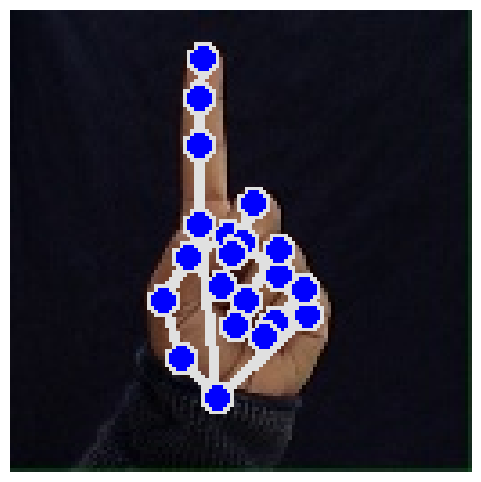

In [41]:
def draw_landmarks_on_image(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        print("Could not load image.")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(image_rgb)

    if not results.multi_hand_landmarks:
        print("No hand detected.")
        return

    annotated = image_rgb.copy()
    for hand_landmarks in results.multi_hand_landmarks:
        mp_drawing.draw_landmarks(
            annotated,
            hand_landmarks,
            mp_hands.HAND_CONNECTIONS
        )

    plt.figure(figsize=(6, 6))
    plt.imshow(annotated)
    plt.axis("off")
    plt.show()

sample_image = train_df.iloc[0]["image_path"]
draw_landmarks_on_image(sample_image)